In [1]:
#Importing libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

In [2]:
#Device agnostic code
if torch.cuda.is_available():
    device = "cuda" 
else:
    device = "cpu" 
    
#Resizing images and turning them into tensors for matrix operations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

#Creating Dataloaders for Magnetic Resonance Imaging
MRI = datasets.ImageFolder(root='/kaggle/input/brain-tumor-multimodal-image-ct-and-mri/Dataset/Brain Tumor MRI images', transform=transform)

MRI_dataloader = DataLoader(MRI, batch_size=32, shuffle=True)
MRI_train_size = int(0.8 * len(MRI))
MRI_test_size = len(MRI) - MRI_train_size  

MRI_train_dataset, MRI_test_dataset = random_split(MRI, [MRI_train_size, MRI_test_size])

MRI_train_loader = DataLoader(MRI_train_dataset, batch_size=32, shuffle=True)
MRI_test_loader = DataLoader(MRI_test_dataset, batch_size=32, shuffle=True)

print("MRI Training set size:", len(MRI_train_dataset))
print("MRI Testing set size:", len(MRI_test_dataset))

MRI Training set size: 4000
MRI Testing set size: 1000


In [3]:
print("MRI Classes:", MRI.classes)

MRI Classes: ['Healthy', 'Tumor']


In [4]:
#Function for showing batches

def show_MRI_batch(dataloader, title="Batch of CT Images"):
    images, labels = next(iter(dataloader))
    fig, axes = plt.subplots(4, 8, figsize=(15, 8))
    fig.suptitle(title)
    
    for i, ax in enumerate(axes.flatten()):
        if i < len(images):
            img = images[i].permute(1, 2, 0)  # Convert tensor image for plotting
            ax.imshow(img)
            ax.set_title(MRI.classes[labels[i]])
            ax.axis('off')
    plt.show()

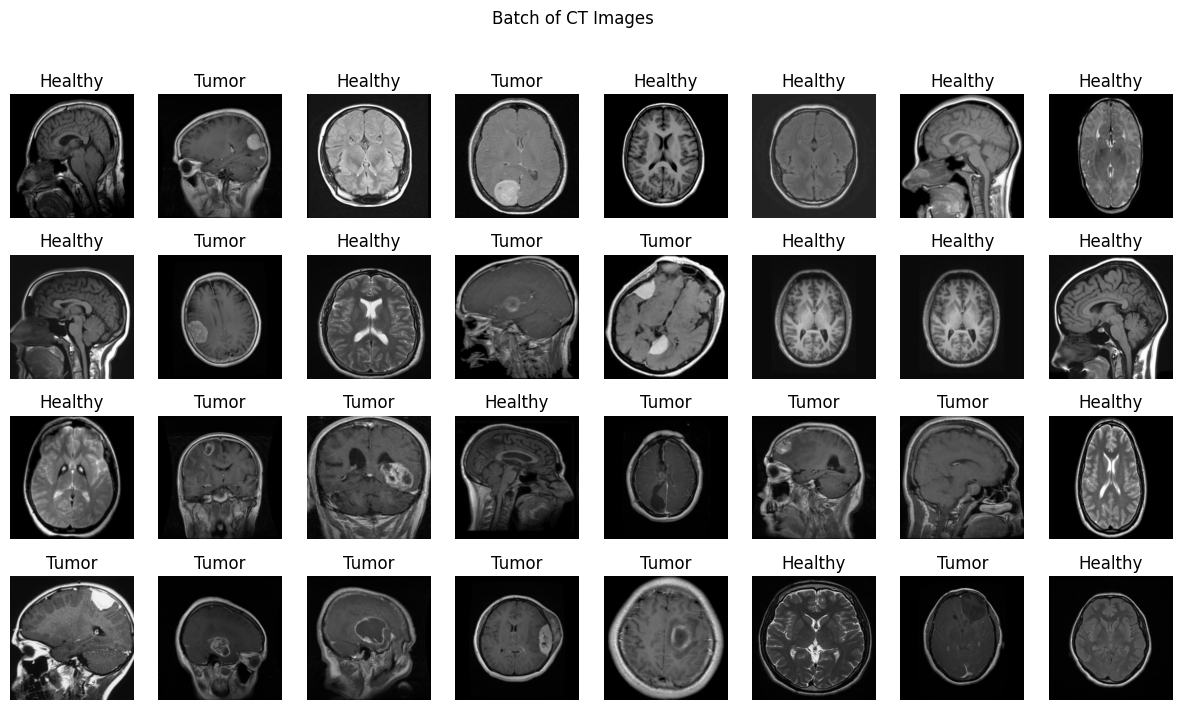

In [5]:
show_MRI_batch(MRI_train_loader)

In [6]:
#Magnetic Resonance Imaging CNN Model

class MRIModel(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.layer_stack = nn.Sequential(
            # First convolutional layer
            nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=3, stride=1, padding=1),  # Output: 224x224x32
            nn.ReLU(),
            
            # Second convolutional layer
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),  # Output: 224x224x64
            nn.ReLU(),
            
            # First max pooling layer
            nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 112x112x64
            
            # Third convolutional layer
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),  # Output: 112x112x128
            nn.ReLU(),
            
            # Fourth convolutional layer
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1),  # Output: 112x112x256
            nn.ReLU(),
            
            # Second max pooling layer
            nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 56x56x256
            
            # Fifth convolutional layer
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1),  # Output: 56x56x512
            nn.ReLU(),
            
            # Sixth convolutional layer
            nn.Conv2d(in_channels=512, out_channels=1024, kernel_size=3, stride=1, padding=1),  # Output: 56x56x1024
            nn.ReLU(),
            
            # Third max pooling layer
            nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 28x28x1024
            
            # Fourth max pooling layer 
            nn.MaxPool2d(kernel_size=4, stride=4),  # Output: 7x7x1024
            
            # Flatten layer
            nn.Flatten(),  # Output: 7x7x1024 = 50176
            
            # Fully connected layer
            nn.Linear(in_features=7 * 7 * 1024, out_features=256),  # Reduce dimensionality
            nn.ReLU(),
            nn.Dropout(0.5),  # Dropout to prevent overfitting
            
            # Final output layer
            nn.Linear(in_features=256, out_features=num_classes)  # Output: 2 (num_classes)
        )
    
    def forward(self, x):
        return self.layer_stack(x)

# Instantiate the model
mri_model = MRIModel(in_channels=3, num_classes=2)  # Assuming RGB input (3 channels)
print(mri_model)

MRIModel(
  (layer_stack): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (16): Flatten(start_dim=1, end_dim=-1)
    (17): Linear(in_fea

In [7]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(mri_model.parameters(),lr=0.001)
mri_model=mri_model.to(device)

In [8]:
#Train and Test Loop for PyTorch

from tqdm import tqdm

num_epochs = 10

mri_all_labels = []
mri_all_predictions = []

for epoch in range(num_epochs):
    mri_model.train()
    running_loss = 0.0
    for images, labels in tqdm(MRI_train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = mri_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

    mri_model.eval()
    correct = 0
    total = 0
    
    with torch.inference_mode():
        for images, labels in tqdm(MRI_test_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = mri_model(images)
            _, predicted = torch.max(outputs, 1)

            mri_all_labels.extend(labels.cpu().numpy())
            mri_all_predictions.extend(predicted.cpu().numpy())
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(MRI_train_loader):.4f},Accuracy of the model on the validation set: {100 * correct / total:.2f}")

100%|██████████| 32/32 [00:12<00:00,  2.62it/s]


Epoch [1/10], Loss: 0.6010,Accuracy of the model on the validation set: 80.60


100%|██████████| 32/32 [00:10<00:00,  3.13it/s]


Epoch [2/10], Loss: 0.3599,Accuracy of the model on the validation set: 87.00


100%|██████████| 32/32 [00:10<00:00,  3.14it/s]


...

Epoch [8/10], Loss: 0.1275,Accuracy of the model on the validation set: 94.10


100%|██████████| 32/32 [00:10<00:00,  3.15it/s]


Epoch [9/10], Loss: 0.1210,Accuracy of the model on the validation set: 91.10


100%|██████████| 32/32 [00:10<00:00,  3.12it/s]

Epoch [10/10], Loss: 0.1059,Accuracy of the model on the validation set: 96.80


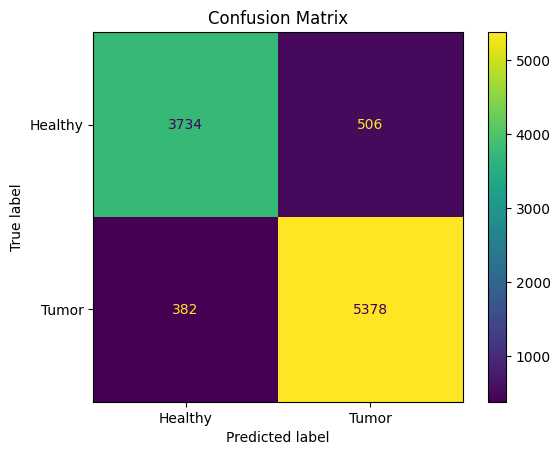

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(mri_all_labels, mri_all_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Tumor"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [10]:
torch.save(mri_model, 'mri_model.pth')  # Save the model
mri_saved = torch.load('mri_model.pth')  # Load the model
mri_saved = mri_saved.to(device)

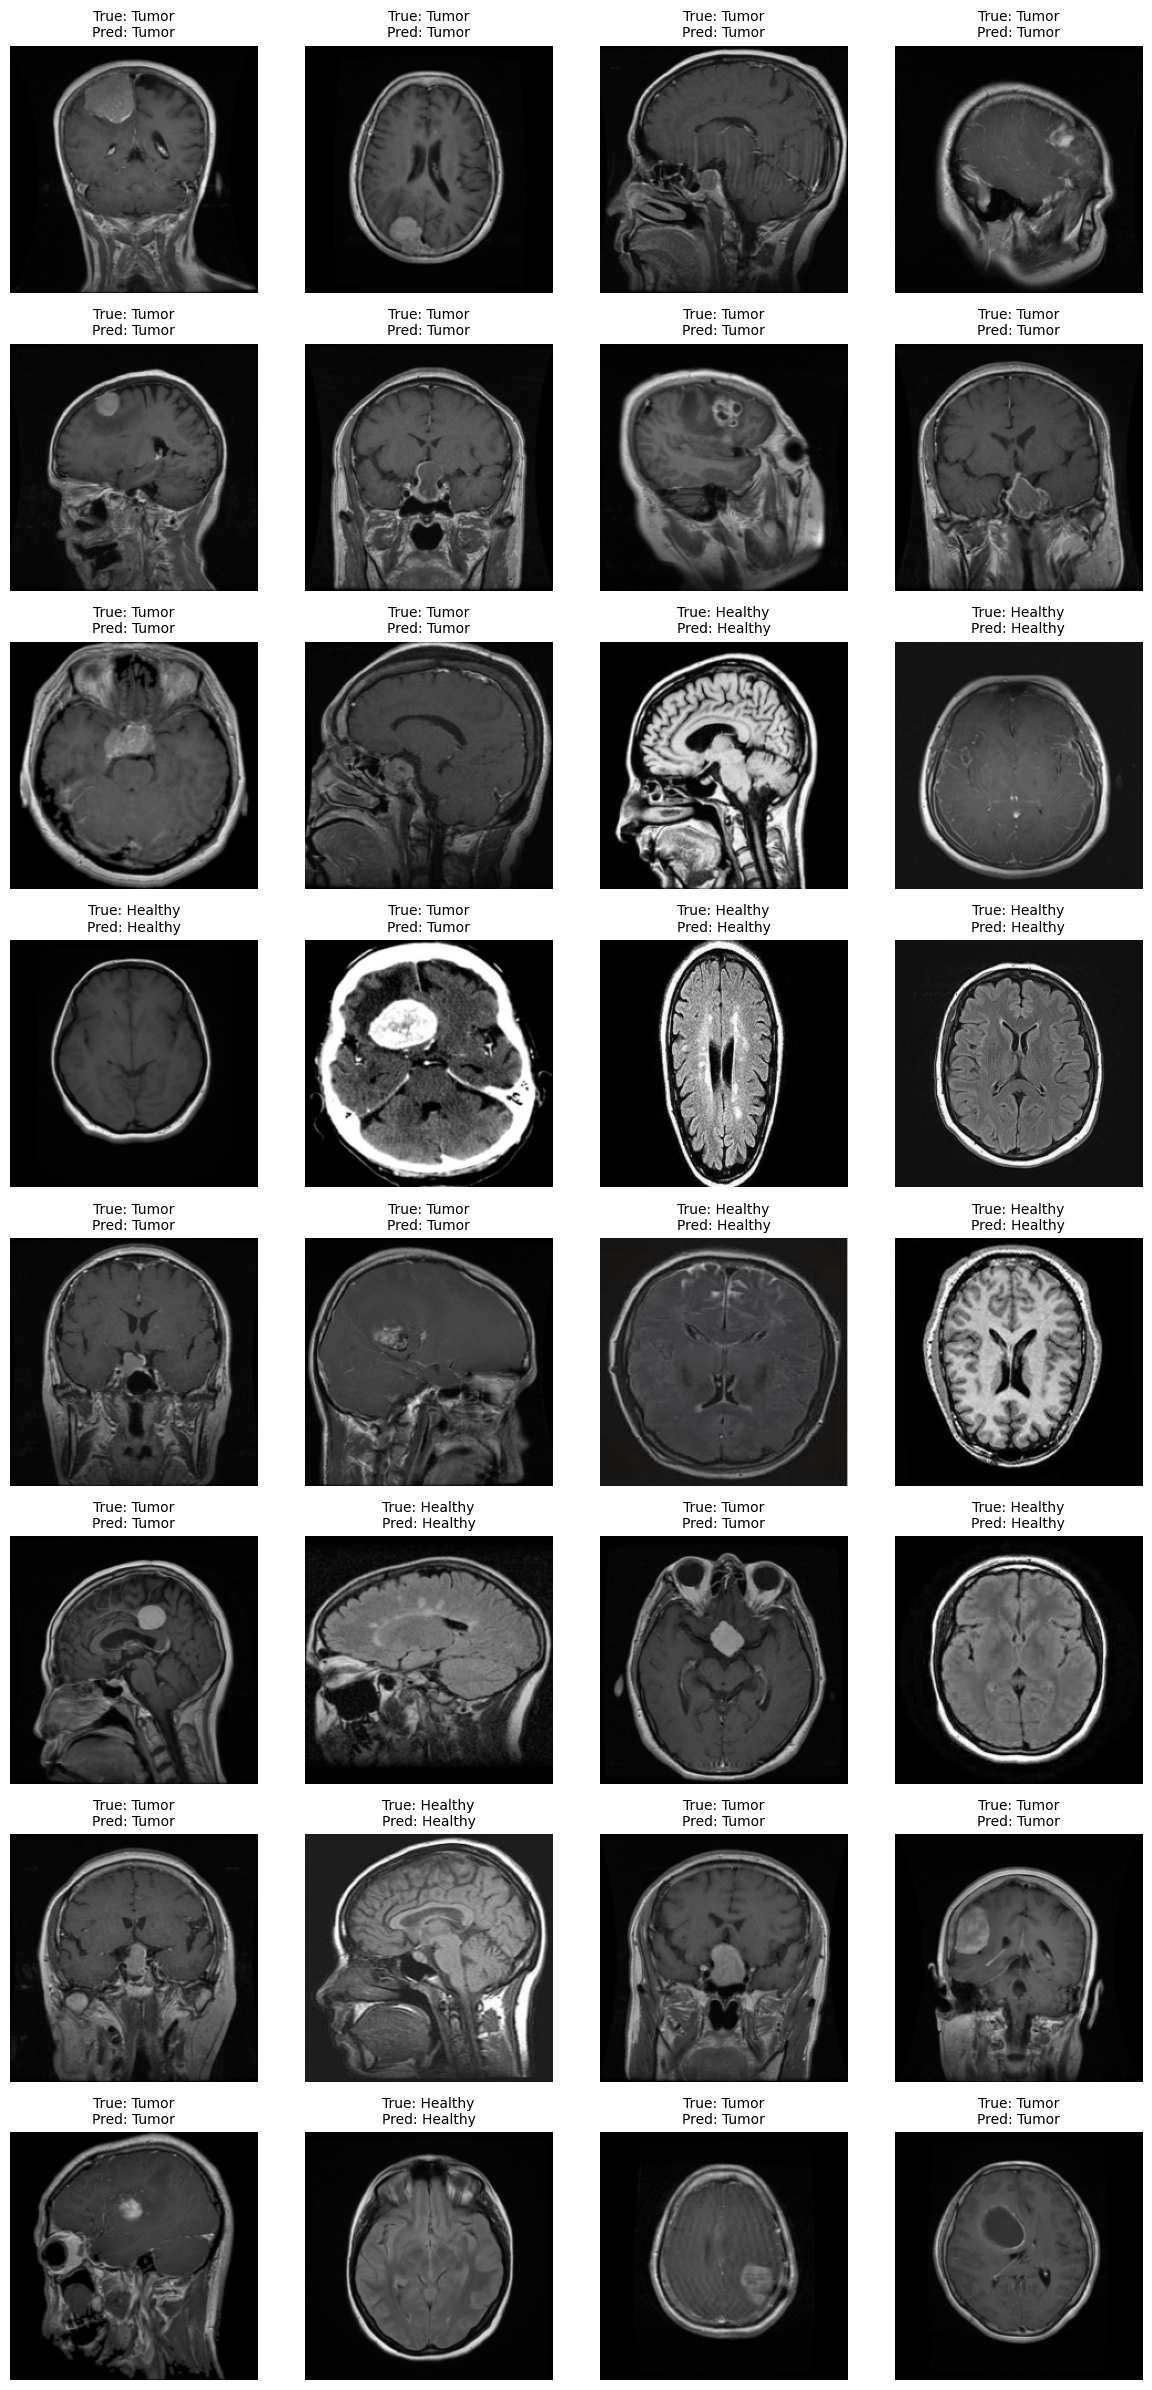

In [11]:
#Predicting some labels

mri_images, mri_labels = next(iter(MRI_test_loader))

mri_images, mri_labels = mri_images.to(device), mri_labels.to(device)

mri_saved.eval()

logits = mri_saved(mri_images) 
_, predicted_indices = torch.max(logits, 1) 

true_labels = [MRI.classes[label.item()] for label in mri_labels]
predicted_labels = [MRI.classes[pred.item()] for pred in predicted_indices]

batch_size = len(mri_images)
cols = 4  
rows = (batch_size + cols - 1) // cols

plt.figure(figsize=(12, rows * 3))

for idx in range(batch_size):
    plt.subplot(rows, cols, idx + 1)
    img = mri_images[idx].cpu().permute(1, 2, 0).numpy()
    true_label = true_labels[idx]
    predicted_label = predicted_labels[idx]
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {predicted_label}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()